<a href="https://colab.research.google.com/github/zbh3un/4002_proj1/blob/main/official_code_w_emojis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install vaderSentiment transformers torch emoji -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

reviews_df = pd.read_csv("reviews.csv")
reviews_df = reviews_df.drop(['Time_submitted', 'Reply', 'Total_thumbsup'], axis=1)
reviews_df.head()

,Review,Rating
0,"Great music service, the audio is high quality...",5
1,Please ignore previous negative rating. This a...,5
2,"This pop-up ""Get the best Spotify experience o...",4
3,Really buggy and terrible to use as of recently,1
4,Dear Spotify why do I get songs that I didn't ...,1


In [ ]:
# VADER
vader = SentimentIntensityAnalyzer()
compounds = [vader.polarity_scores(t)['compound'] for t in reviews_df['Review']]
reviews_df['vader_compound'] = compounds
reviews_df['vader_predicted_rating'] = [int(round((c + 1) * 2 + 1)) for c in compounds]
reviews_df

,Review,Rating,vader_compound,vader_predicted_rating
0,"Great music service, the audio is high quality...",5,0.9211,5
1,Please ignore previous negative rating. This a...,5,0.6249,4
2,"This pop-up ""Get the best Spotify experience o...",4,0.5859,4
3,Really buggy and terrible to use as of recently,1,-0.5209,2
4,Dear Spotify why do I get songs that I didn't ...,1,0.7149,4
...,...,...,...,...
61589,Even though it was communicated that lyrics fe...,1,-0.2960,2
61590,"Use to be sooo good back when I had it, and wh...",1,0.9143,5
61591,This app would be good if not for it taking ov...,2,-0.9633,1
61592,The app is good hard to navigate and won't jus...,2,0.8074,5


In [ ]:
# HuggingFace BERT
hf_pipe = pipeline("sentiment-analysis",
                   model="nlptown/bert-base-multilingual-uncased-sentiment",
                   device=0, truncation=True, max_length=512)

texts = [t if t.strip() else "neutral" for t in reviews_df['Review']]

results = []
for i in range(0, len(texts), 32):
    results.extend(hf_pipe(texts[i:i+32]))

reviews_df['hf_predicted_rating'] = [int(r['label'].split()[0]) for r in results]
reviews_df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Review,Rating,vader_compound,vader_predicted_rating,hf_predicted_rating
0,"Great music service, the audio is high quality...",5,0.9211,5,5
1,Please ignore previous negative rating. This a...,5,0.6249,4,5
2,"This pop-up ""Get the best Spotify experience o...",4,0.5859,4,1
3,Really buggy and terrible to use as of recently,1,-0.5209,2,1
4,Dear Spotify why do I get songs that I didn't ...,1,0.7149,4,1
...,...,...,...,...,...
61589,Even though it was communicated that lyrics fe...,1,-0.2960,2,1
61590,"Use to be sooo good back when I had it, and wh...",1,0.9143,5,1
61591,This app would be good if not for it taking ov...,2,-0.9633,1,2
61592,The app is good hard to navigate and won't jus...,2,0.8074,5,3


In [ ]:
# accuracy results
vader_exact = (reviews_df['Rating'] == reviews_df['vader_predicted_rating']).mean() * 100
vader_off1 = (abs(reviews_df['Rating'] - reviews_df['vader_predicted_rating']) <= 1).mean() * 100
vader_diff = abs(reviews_df['Rating'] - reviews_df['vader_predicted_rating']).mean()

hf_exact = (reviews_df['Rating'] == reviews_df['hf_predicted_rating']).mean() * 100
hf_off1 = (abs(reviews_df['Rating'] - reviews_df['hf_predicted_rating']) <= 1).mean() * 100
hf_diff = abs(reviews_df['Rating'] - reviews_df['hf_predicted_rating']).mean()

pd.DataFrame({
    'Model': ['VADER', 'HuggingFace'],
    'Exact Match %': [vader_exact, hf_exact],
    'Off-by-One %': [vader_off1, hf_off1],
    'Avg Error': [vader_diff, hf_diff]
})

,Model,Exact Match %,Off-by-One %,Avg Error
0,VADER,31.663798,71.805695,1.091502
1,HuggingFace,58.638828,86.558756,0.621294


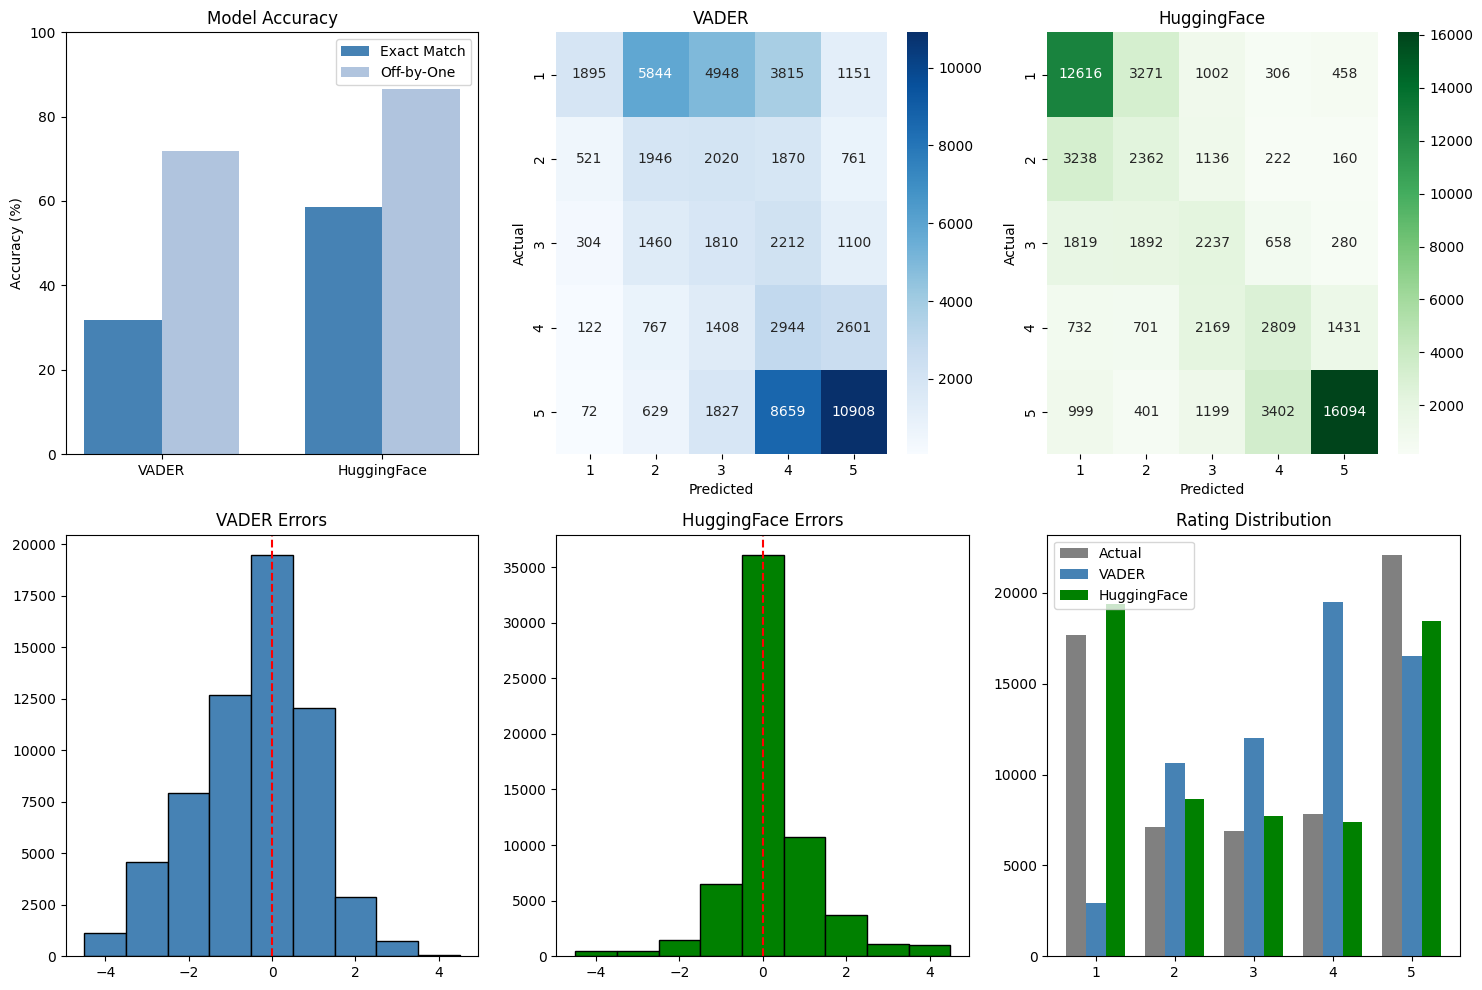

In [ ]:
# visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# accuracy comparison
x = np.arange(2)
axes[0, 0].bar(x - 0.175, [vader_exact, hf_exact], 0.35, label='Exact Match', color='steelblue')
axes[0, 0].bar(x + 0.175, [vader_off1, hf_off1], 0.35, label='Off-by-One', color='lightsteelblue')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(['VADER', 'HuggingFace'])
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 100)

# confusion matrices
sns.heatmap(pd.crosstab(reviews_df['Rating'], reviews_df['vader_predicted_rating']),
            annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('VADER')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

sns.heatmap(pd.crosstab(reviews_df['Rating'], reviews_df['hf_predicted_rating']),
            annot=True, fmt='d', cmap='Greens', ax=axes[0, 2])
axes[0, 2].set_title('HuggingFace')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# error distributions
axes[1, 0].hist(reviews_df['Rating'] - reviews_df['vader_predicted_rating'],
                bins=9, range=(-4.5, 4.5), color='steelblue', edgecolor='black')
axes[1, 0].set_title('VADER Errors')
axes[1, 0].axvline(0, color='red', linestyle='--')

axes[1, 1].hist(reviews_df['Rating'] - reviews_df['hf_predicted_rating'],
                bins=9, range=(-4.5, 4.5), color='green', edgecolor='black')
axes[1, 1].set_title('HuggingFace Errors')
axes[1, 1].axvline(0, color='red', linestyle='--')

# rating distribution
x = np.arange(1, 6)
actual = [sum(reviews_df['Rating'] == i) for i in x]
vader_pred = [sum(reviews_df['vader_predicted_rating'] == i) for i in x]
hf_pred = [sum(reviews_df['hf_predicted_rating'] == i) for i in x]
axes[1, 2].bar(x - 0.25, actual, 0.25, label='Actual', color='gray')
axes[1, 2].bar(x, vader_pred, 0.25, label='VADER', color='steelblue')
axes[1, 2].bar(x + 0.25, hf_pred, 0.25, label='HuggingFace', color='green')
axes[1, 2].set_title('Rating Distribution')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# examples where HuggingFace is better
sample_df = reviews_df[['Review', 'Rating', 'vader_predicted_rating', 'hf_predicted_rating']].copy()
sample_df['vader_error'] = abs(sample_df['Rating'] - sample_df['vader_predicted_rating'])
sample_df['hf_error'] = abs(sample_df['Rating'] - sample_df['hf_predicted_rating'])

sample_df[sample_df['hf_error'] < sample_df['vader_error']].head(5)

,Review,Rating,vader_predicted_rating,hf_predicted_rating,vader_error,hf_error
1,Please ignore previous negative rating. This a...,5,4,5,1,0
3,Really buggy and terrible to use as of recently,1,2,1,1,0
4,Dear Spotify why do I get songs that I didn't ...,1,4,1,3,0
6,I love the selection and the lyrics are provid...,5,4,5,1,0
9,"I'm deleting this app, for the following reaso...",1,4,1,3,0


In [ ]:
# examples where VADER is better
sample_df[sample_df['vader_error'] < sample_df['hf_error']].head(5)

,Review,Rating,vader_predicted_rating,hf_predicted_rating,vader_error,hf_error
2,"This pop-up ""Get the best Spotify experience o...",4,4,1,0,3
8,It's a great app and the best mp3 music app I ...,5,5,4,0,1
21,His voice is so sweet and hearable,4,4,5,0,1
22,I logged out on my acc but when I tried to ope...,3,3,1,0,2
24,An amazing music experience,4,4,5,0,1


In [ ]:
# to show that it still has emojis
pd.set_option('display.max_colwidth', None)
reviews_df[['Review']].head(20)

,Review
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support."
1,Please ignore previous negative rating. This app is super great. I give it five stars+
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this."
3,Really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?
5,The player controls sometimes disappear for no reason. App restart forgets what I was playing but fixes the issue.
6,I love the selection and the lyrics are provided with the song you're listening to!
7,"Still extremely slow when changing storage to external sd card.. I'm convinced this is done on purpose, spotify knows of this issue and has done NOTHING to solve it! Over time I have changed sd cards, each being faster in read, write speeds(all samsung brand). And please add ""don't like song"" so it will never appear again in my searches or playlists."
8,"It's a great app and the best mp3 music app I have ever used but there is one problem that, why can't we play some songs or find some songs? despite this the app is wonderful I recommend it. it's just the best."
9,"I'm deleting this app, for the following reasons: This app now has a failing business model. Whether streaming services like it, or not: the consumer doesn't want to pay for music they can't fully own, and 6 ads successively, upon logging in, before a single song, is too much. Closed the app during ad number 6, and I'm more patient than most. If those are the only ways you can profit: you've already peaked. All that's left is your decline."
